In [17]:
import seaborn as sns
import pandas as pd
import numpy as np

In [18]:
train_df = pd.read_excel('/workspaces/SML/SML /Exp 8/train.xlsx')
train_df
test_df = pd.read_excel('/workspaces/SML/SML /Exp 8/test.xlsx')
test_df

,Loan_ID,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area,Loan_Status
0,7,1,1,0,0,2333,1516.0,95,360,2,1
1,8,1,1,3,0,3036,2504.0,158,360,0,0
2,13,1,1,2,0,3073,8106.0,200,360,2,1
3,20,1,1,0,1,2600,3500.0,115,0,2,1
4,22,1,1,1,0,5955,5625.0,315,360,2,1
...,...,...,...,...,...,...,...,...,...,...,...
172,599,1,1,0,1,9963,0.0,180,360,1,1
173,604,1,0,0,0,3676,4301.0,172,360,1,1
174,605,0,1,1,0,12000,0.0,496,360,0,1
175,608,1,1,2,0,3987,1411.0,157,360,1,1


drop loanid column

In [19]:
train_df = train_df.drop('Loan_ID',axis=1)
train_df


,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area,Loan_Status
0,1,0,0,0,5849,0,0,360,2,1
1,1,1,1,0,4583,1508,128,360,1,0
2,1,1,0,1,3000,0,66,360,2,1
3,1,1,0,0,2583,2358,120,360,2,1
4,1,0,0,0,6000,0,141,360,2,1
...,...,...,...,...,...,...,...,...,...,...
432,1,1,0,0,3232,1950,108,360,1,1
433,0,0,0,0,2900,0,71,360,1,1
434,1,1,3,0,4106,0,40,180,1,1
435,1,1,1,0,8072,240,253,360,2,1


In [20]:
test_df

,Loan_ID,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area,Loan_Status
0,7,1,1,0,0,2333,1516.0,95,360,2,1
1,8,1,1,3,0,3036,2504.0,158,360,0,0
2,13,1,1,2,0,3073,8106.0,200,360,2,1
3,20,1,1,0,1,2600,3500.0,115,0,2,1
4,22,1,1,1,0,5955,5625.0,315,360,2,1
...,...,...,...,...,...,...,...,...,...,...,...
172,599,1,1,0,1,9963,0.0,180,360,1,1
173,604,1,0,0,0,3676,4301.0,172,360,1,1
174,605,0,1,1,0,12000,0.0,496,360,0,1
175,608,1,1,2,0,3987,1411.0,157,360,1,1


In [21]:
test_df = test_df.drop('Loan_ID',axis=1)
test_df

,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area,Loan_Status
0,1,1,0,0,2333,1516.0,95,360,2,1
1,1,1,3,0,3036,2504.0,158,360,0,0
2,1,1,2,0,3073,8106.0,200,360,2,1
3,1,1,0,1,2600,3500.0,115,0,2,1
4,1,1,1,0,5955,5625.0,315,360,2,1
...,...,...,...,...,...,...,...,...,...,...
172,1,1,0,1,9963,0.0,180,360,1,1
173,1,0,0,0,3676,4301.0,172,360,1,1
174,0,1,1,0,12000,0.0,496,360,0,1
175,1,1,2,0,3987,1411.0,157,360,1,1


In [22]:
train_df.isnull().sum()

Gender               0
Married              0
Dependents           0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Property_Area        0
Loan_Status          0
dtype: int64

In [23]:
train_df = train_df.fillna(0)

CASE 1. WITHOUT FEATURE ENGINEERING

In [24]:
X = train_df.drop(columns=['Loan_Status'])
y = train_df['Loan_Status']

In [25]:
print(X)

     Gender  Married  Dependents  Self_Employed  ApplicantIncome  \
0         1        0           0              0             5849   
1         1        1           1              0             4583   
2         1        1           0              1             3000   
3         1        1           0              0             2583   
4         1        0           0              0             6000   
..      ...      ...         ...            ...              ...   
432       1        1           0              0             3232   
433       0        0           0              0             2900   
434       1        1           3              0             4106   
435       1        1           1              0             8072   
436       1        1           2              0             7583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Property_Area  
0                    0           0               360              2  
1                 1508         128         

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [32]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf',gamma=0.67,random_state=42)
classifier.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.67
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [33]:
y_pred = classifier.predict(x_test)

In [34]:
#Make the confusion matrix
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(y_test,y_pred)
print(cm)
accuracy_score(y_test,y_pred)

[[ 0 28]
 [ 0 60]]


0.6818181818181818

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scale',StandardScaler()),
    ('svm',SVC(class_weight='balanced',probability=True))
])

In [37]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'svm__C': [0.1,1,10,50],
    'svm__gamma':['scale',0.01,0.1],
    'svm__kernel':['rbf','linear']
}
grid = GridSearchCV(pipeline,param_grid,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
print("Best Parametrs:",grid.best_params_)
print("Best Score",grid.best_score_)

Best Parametrs: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Best Score 0.5673291925465838


In [38]:
import matplotlib.pyplot as plt

In [41]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(x_train)
X_test_scaled = sc.transform(x_test)

In [42]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

/tmp/ipykernel_7642/1524277788.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


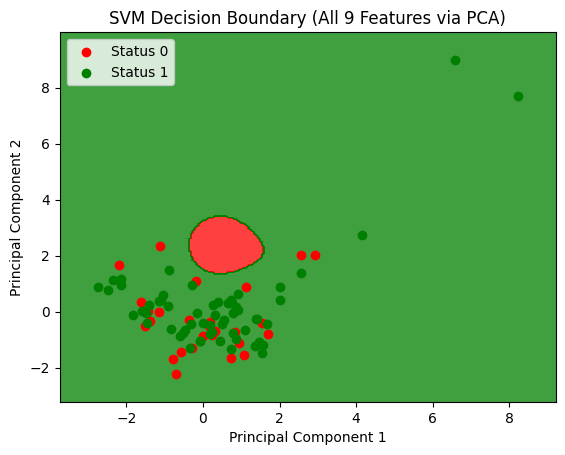

In [43]:
classifier = SVC(kernel='rbf', gamma=0.67, random_state=42)
classifier.fit(X_train_pca, y_train)

# 6. Create Meshgrid for visualization (Safe memory usage)
X_set, y_set = X_test_pca, y_test.values
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.05),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.05)
)

# 7. Plot Boundary and Points
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('red', 'green')))

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=f'Status {j}')

plt.title('SVM Decision Boundary (All 9 Features via PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()